In [8]:
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

# Load and MERGE the published GTFS feeds in GTFS_data/.
# Each subfolder is one full GTFS feed (a dated snapshot of one company):
#   TransNit_20260320      -> TransNit
#   TransOcenico_20260315  -> TransOceanico (early/mid month)
#   TransOceanico_20260329 -> TransOceanico (late month)
GTFS_DIR = "GTFS_data"
FEED_DIRS = sorted(d for d in glob.glob(os.path.join(GTFS_DIR, "*")) if os.path.isdir(d))
# Sorted so "TransNit_*" comes first -> it wins on the stop_ids shared by both companies.

# Primary key(s) per GTFS file. On merge we keep one row per key (keep="first"):
#  - stops are shared by both companies (112 ids); keep-first overwrites duplicates with one row.
#  - the two TransOceanico snapshots repeat identical auxiliary data; keep-first collapses it.
#  - trips / stop_times / shapes are unioned (their ids are disjoint across feeds).
#  - agency_id is NOT unique across operators (both use id "1"), so de-dup agency on (id, name).
DEDUP_KEYS = {
    "agency.txt":         ["agency_id", "agency_name"],
    "routes.txt":         ["route_id"],
    "trips.txt":          ["trip_id"],
    "stops.txt":          ["stop_id"],
    "stop_times.txt":     ["trip_id", "stop_sequence"],
    "calendar.txt":       ["service_id"],
    "calendar_dates.txt": ["service_id", "date"],
    "shapes.txt":         ["shape_id", "shape_pt_sequence"],
}


def load_gtfs_file(feed_dirs, file_name):
    """Read `file_name` from every feed folder, concatenate, de-duplicate by key."""
    frames = []
    for fd in feed_dirs:
        path = os.path.join(fd, file_name)
        if not os.path.isfile(path):
            continue
        df = pd.read_csv(path, quotechar='"')
        df.columns = df.columns.str.strip()
        df["feed_source"] = os.path.basename(fd)
        frames.append(df)
    if not frames:
        print(f"Warning: {file_name} not found in any feed.")
        return None
    merged = pd.concat(frames, ignore_index=True)
    keys = DEDUP_KEYS.get(file_name)
    if keys and all(k in merged.columns for k in keys):
        before = len(merged)
        merged = merged.drop_duplicates(subset=keys, keep="first").reset_index(drop=True)
        print(f"{file_name:18s}: {before:>8} -> {len(merged):>8} rows (de-dup on {keys})")
    else:
        print(f"{file_name:18s}: {len(merged):>8} rows (union, no de-dup)")
    return merged


print("Feeds found:", [os.path.basename(d) for d in FEED_DIRS], "\n")

# Load and merge essential files across all feeds
agency     = load_gtfs_file(FEED_DIRS, 'agency.txt')
routes     = load_gtfs_file(FEED_DIRS, 'routes.txt')
trips      = load_gtfs_file(FEED_DIRS, 'trips.txt')
stops      = load_gtfs_file(FEED_DIRS, 'stops.txt')
stop_times = load_gtfs_file(FEED_DIRS, 'stop_times.txt')
calendar   = load_gtfs_file(FEED_DIRS, 'calendar.txt')
shapes     = load_gtfs_file(FEED_DIRS, 'shapes.txt')  # Optional but highly recommended

print("\nMerged feed sources:", sorted(trips['feed_source'].unique()))

Feeds found: ['TransNit_20260320', 'TransOceanico_20260329', 'TransOcenico_20260315'] 

agency.txt        :        5 ->        4 rows (de-dup on ['agency_id', 'agency_name'])
routes.txt        :       81 ->       55 rows (de-dup on ['route_id'])
trips.txt         :    19846 ->    16036 rows (de-dup on ['trip_id'])
stops.txt         :     1822 ->     1087 rows (de-dup on ['stop_id'])
stop_times.txt    :   760265 ->   592498 rows (de-dup on ['trip_id', 'stop_sequence'])
calendar.txt      :      218 ->      174 rows (de-dup on ['service_id'])
shapes.txt        :    78652 ->    51687 rows (de-dup on ['shape_id', 'shape_pt_sequence'])

Merged feed sources: ['TransNit_20260320', 'TransOceanico_20260329', 'TransOcenico_20260315']


In [9]:
print("=== GTFS Dataset Characterization ===")
print(f"Agency Name(s): {', '.join(agency['agency_name'].dropna().unique())}")
print(f"Total Routes: {routes['route_id'].nunique()}")
print(f"Total Stops: {stops['stop_id'].nunique()}")
print(f"Total Scheduled Trips: {trips['trip_id'].nunique()}")

# Breakdown by transit mode (route_type)
# 3 = Bus, 1 = Subway, 2 = Rail, 0 = Tram, etc.
if 'route_type' in routes.columns:
    print("\n--- Route Types Breakdown ---")
    print(routes['route_type'].value_counts())

=== GTFS Dataset Characterization ===
Agency Name(s): VIAÇÃO ARAÇATUBA, AUTO ÔNIBUS BRASÍLIA, AUTO LOTAÇÃO INGÁ - MUNICIPAL, CONSÓRCIO TRANSOCEÂNICO
Total Routes: 55
Total Stops: 1087
Total Scheduled Trips: 16036

--- Route Types Breakdown ---
route_type
3    55
Name: count, dtype: int64


Network Bounding Box: [-43.45780182 -22.97023582 -42.69742203 -22.56127167]
Successfully generated 139 unique spatial route shapes.


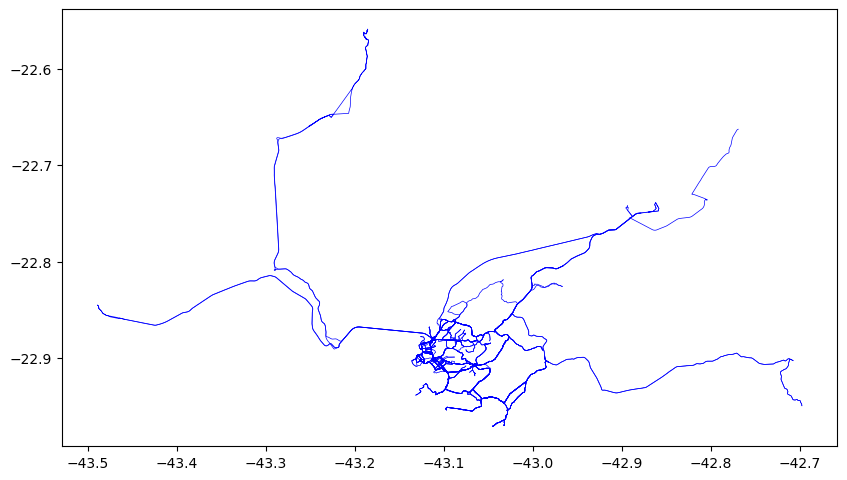

In [10]:
# Convert Stops to a GeoDataFrame
gdf_stops = gpd.GeoDataFrame(
    stops, 
    geometry=gpd.points_from_xy(stops.stop_lon, stops.stop_lat),
    crs="EPSG:4326"
)

print(f"Network Bounding Box: {gdf_stops.total_bounds}")

# Reconstruct Route Shapes (Lines) if shapes.txt exists
if shapes is not None:
    # Sort to ensure the lines are drawn in the correct sequence
    shapes = shapes.sort_values(by=['shape_id', 'shape_pt_sequence'])
    
    # Group points into LineStrings
    shape_lines = shapes.groupby('shape_id').apply(
        lambda g: LineString(zip(g['shape_pt_lon'], g['shape_pt_lat'])),
        include_groups=False
    )
    
    gdf_shapes = gpd.GeoDataFrame(shape_lines, columns=['geometry'], crs="EPSG:4326")
    print(f"Successfully generated {len(gdf_shapes)} unique spatial route shapes.")
    
    # Quick plot of the network layout
    gdf_shapes.plot(color='blue', linewidth=0.5, figsize=(10, 10))

         trip_id arrival_time departure_time    stop_id  stop_sequence  \
0  1219424_D_1_1     10:00:00       10:00:00  236745087              1   
1  1219424_D_1_1     10:01:27       10:01:27  236456995              2   
2  1219424_D_1_1     10:02:27       10:02:27  233045333              3   
3  1219424_D_1_1     10:02:58       10:02:58  233045332              4   
4  1219424_D_1_1     10:05:10       10:05:10  137366407              5   

   stop_headsign  pickup_type  drop_off_type        feed_source  
0            NaN            0              0  TransNit_20260320  
1            NaN            0              0  TransNit_20260320  
2            NaN            0              0  TransNit_20260320  
3            NaN            0              0  TransNit_20260320  
4            NaN            0              0  TransNit_20260320  


<Axes: title={'center': 'Temporal Activity Profile (24-Hour Wrapped Cycle)'}, xlabel='Hour of Day', ylabel='Number of Scheduled Stop Events'>

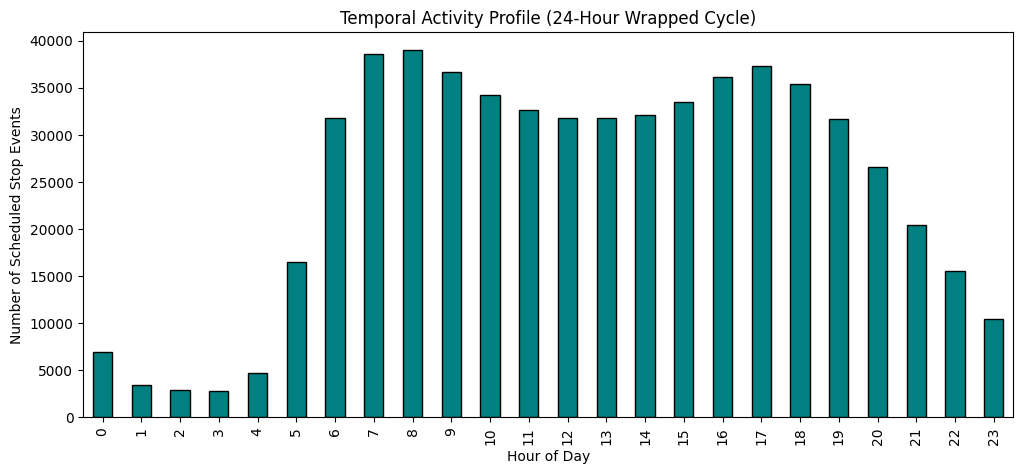

In [11]:
print(stop_times.head())

# Clean column names to make sure we are hitting the right target
stop_times.columns = stop_times.columns.str.strip()

# Extract hours using a raw Python list comprehension
hours = []
for time_string in stop_times['departure_time']:
    # Clean up quotes or spaces, then split by ':' and grab the FIRST element
    clean_str = str(time_string).replace('"', '').strip()
    hour_part = clean_str.split(':')  # <-- Added here to get the string '07'
    # Try to convert to integer, use -1 if it's corrupted data
    try:
        hours.append(int(hour_part[0]))
    except ValueError:
        hours.append(-1)

# Assign it back to the dataframe
stop_times['departure_hour'] = hours

# Filter out parsing errors AND wrap hours past midnight into a 24h cycle
valid_hours = stop_times[stop_times['departure_hour'] >= 0].copy()
valid_hours['departure_hour'] = valid_hours['departure_hour'] % 24  # 25 becomes 1, 26 becomes 2, etc.

# Count and Plot
hourly_activity = valid_hours['departure_hour'].value_counts().sort_index()

hourly_activity.plot(
    kind='bar', 
    figsize=(12, 5), 
    title="Temporal Activity Profile (24-Hour Wrapped Cycle)",
    xlabel="Hour of Day", 
    ylabel="Number of Scheduled Stop Events",
    color='teal',
    edgecolor='black'
)

In [12]:
# Merge trips and stop_times to get route context
merged_trips = pd.merge(stop_times, trips, on='trip_id', how='inner')

# Filter for Morning Peak (7 AM to 9 AM)
am_peak = merged_trips[(merged_trips['departure_hour'] >= 7) & (merged_trips['departure_hour'] < 9)]

# Calculate headways per stop per route
# Sort by route, stop, and time sequence
am_peak = am_peak.sort_values(by=['route_id', 'stop_id', 'departure_time'])

# Convert departure time to minutes from midnight for easy math
def to_minutes(time_str):
    h, m, _ = map(int, time_str.split(':'))
    return h * 60 + m

am_peak['departure_minutes'] = am_peak['departure_time'].apply(to_minutes)

# Calculate difference between consecutive trips at the same stop for the same route
am_peak['headway_minutes'] = am_peak.groupby(['route_id', 'stop_id'])['departure_minutes'].diff()

# Filter out NaN and potential outliers (e.g., gaps between completely different service patterns)
valid_headways = am_peak['headway_minutes'].dropna()
valid_headways = valid_headways[valid_headways <= 60] 

print(f"Average AM Peak Headway across network: {valid_headways.mean():.2f} minutes")
print(f"Median AM Peak Headway: {valid_headways.median():.2f} minutes")

Average AM Peak Headway across network: 4.03 minutes
Median AM Peak Headway: 2.00 minutes


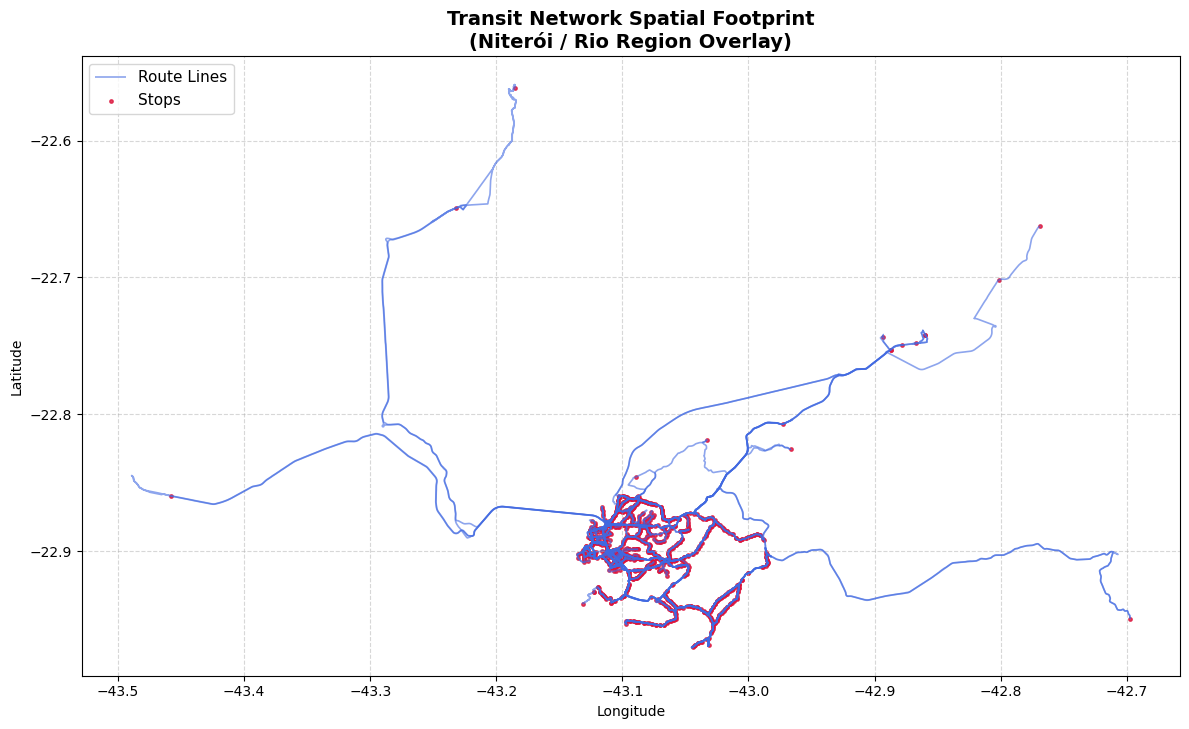

In [13]:
import matplotlib.pyplot as plt

# 1. Double check that we have spatial data generated
if 'gdf_shapes' in locals() and 'gdf_stops' in locals():
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot the transit route shapes
    gdf_shapes.plot(
        ax=ax, 
        color='royalblue', 
        linewidth=1.2, 
        alpha=0.6, 
        label='Route Lines'  # Matplotlib uses this label for the legend
    )
    
    # Plot the stop positions
    gdf_stops.plot(
        ax=ax, 
        color='crimson', 
        markersize=6, 
        alpha=0.8, 
        marker='o', 
        label='Stops'        # Matplotlib uses this label for the legend
    )
    
    # Customize the map presentation
    ax.set_title("Transit Network Spatial Footprint\n(Niterói / Rio Region Overlay)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Let Matplotlib handle the legend automatically without Line2D
    ax.legend(loc='upper left', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Error: Make sure to run Cell 3 first to generate 'gdf_shapes' and 'gdf_stops'.")